In [7]:

from dash import html, dcc, callback, Input, Output, State
import dash_bootstrap_components as dbc
from settings import gc, memory, DSA_BASE_URL, token_info
import dash_ag_grid
from components.carlos_reg_utils import (
    dice_coefficient,
    apply_affine_transform,
    register_fixed_moving,
)
from PIL import Image
import SimpleITK as sitk
import cv2
import base64
import numpy as np

from torchvision import transforms
from lightglue import LightGlue, SuperPoint, DISK, SIFT, ALIKED, DoGHardNet
from lightglue.utils import load_image, rbd

SELECTED ROWS
[{'name': 'E20-106_1 Tau.svs', '_id': '673197b4900c0c0559aefcdd', 'preRotate': 'None', 'size': 2583928797, 'regImageSize': '1024', 'rotation': -21.5, 'scale': 0.855, 'srcImage': '67319791900c0c0559aef563', 'xOffset': -18.315, 'yOffset': 113.132}]
Selected source: 67319791900c0c0559aef563
Selected target: 673197b4900c0c0559aefcdd

Debug: Getting thumbnail images
Fixed image type: <class 'numpy.ndarray'>
Fixed image shape: (927, 1024, 3)
Fixed image dtype: uint8
Moving image type: <class 'numpy.ndarray'>
Moving image shape: (919, 1024, 3)
Moving image dtype: uint8
After RGB conversion:
Fixed image shape: (927, 1024, 3)
Moving image shape: (919, 1024, 3)
Fixed image dtype: uint8
Moving image dtype: uint8
Fixed image min/max: 63 255
Moving image min/max: 53 255
Relative rotation: 0 degrees
Dice coefficient: 0.629
The images are in the same orientation.
0.8186555056243227


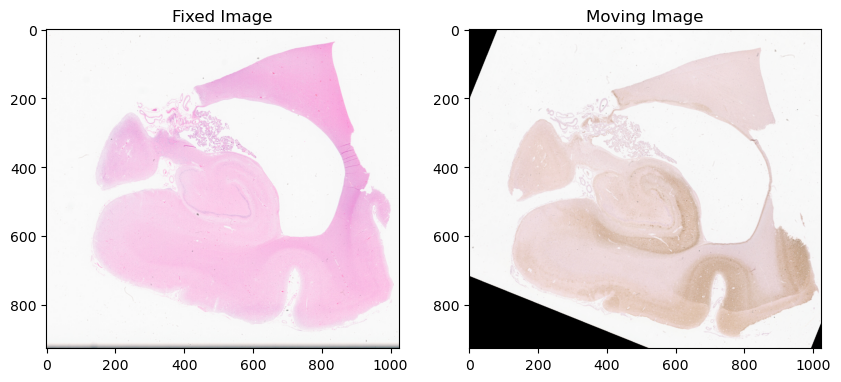

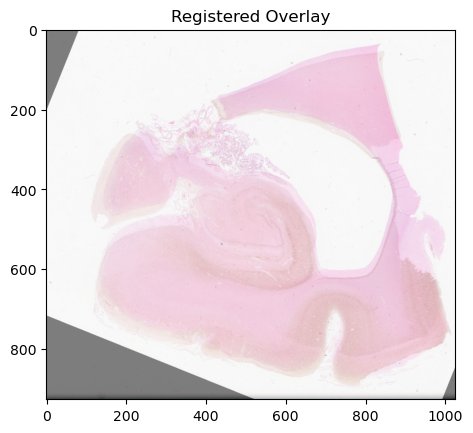

Affine Matrix:
 [[  0.79853674   0.32161167 -20.45047609]
 [ -0.32161167   0.79853674  88.25243654]
 [  0.           0.           1.        ]]
Registration matrix shape: (3, 3)
Registration matrix:
 [[  0.79853674   0.32161167 -20.45047609]
 [ -0.32161167   0.79853674  88.25243654]
 [  0.           0.           1.        ]]
Registered image shape: (927, 1024, 3)
Registered image dtype: uint8
Registered image min/max: 0 254
Resampled image shape: (927, 1024, 3)
Resampled image dtype: uint8
Resampled image min/max: 0 254
Final image shape before encoding: (927, 1024, 3)
Final image dtype: uint8
Final image min/max: 0 254


In [8]:
selected_rows= [
    {'name': 'E20-106_1 Tau.svs', '_id': '673197b4900c0c0559aefcdd',
 'preRotate': 'None', 'size': 2583928797, 'regImageSize': '1024',
  'rotation': -21.5, 'scale': 0.855, 'srcImage': '67319791900c0c0559aef563',
 'xOffset': -18.315, 'yOffset': 113.132
 }]

def update_registered_image(selected_rows):
    print("SELECTED ROWS")
    print(selected_rows)
    if not selected_rows or len(selected_rows) == 0:
        return ""

    selected_item = selected_rows[0]
    src_image_id = selected_item.get("srcImage", "")
    target_id = selected_item.get("_id", "")
    print("Selected source:", src_image_id)
    print("Selected target:", target_id)

    # Get the registered image
    reg_matrix, reg_image, registered_image, mask_reg, mask_orig, src_image = register_fixed_moving(src_image_id, target_id)
    
    print("Registration matrix shape:", reg_matrix.shape)
    print("Registration matrix:\n", reg_matrix)
    print("Registered image shape:", reg_image.shape)
    print("Registered image dtype:", reg_image.dtype)
    print("Registered image min/max:", np.min(reg_image), np.max(reg_image))
    
    # resampled_image = apply_affine_transform(registered_image, reg_matrix)
    resampled_image = sitk.GetArrayFromImage(registered_image)

    print("Resampled image shape:", resampled_image.shape)
    print("Resampled image dtype:", resampled_image.dtype)
    print("Resampled image min/max:", np.min(resampled_image), np.max(resampled_image))

    # Convert to uint8 if not already
    if resampled_image.dtype != np.uint8:
        print("Converting to uint8...")
        resampled_image = (resampled_image * 255).astype(np.uint8)
        print(
            "After uint8 conversion min/max:",
            np.min(resampled_image),
            np.max(resampled_image),
        )

    # Convert grayscale to RGB if needed
    if len(resampled_image.shape) == 2:
        print("Converting grayscale to RGB...")
        resampled_image = cv2.cvtColor(resampled_image, cv2.COLOR_GRAY2RGB)
        print("After RGB conversion shape:", resampled_image.shape)
    
    print("Final image shape before encoding:", resampled_image.shape)
    print("Final image dtype:", resampled_image.dtype)
    print("Final image min/max:", np.min(resampled_image), np.max(resampled_image))
    

    # Encode the image
    success, buffer = cv2.imencode(".png", resampled_image)
    if success:
        registered_thumb = "data:image/png;base64," + base64.b64encode(buffer).decode(
            "utf-8"
        )
        return registered_thumb, resampled_image, registered_image,mask_reg, mask_orig, src_image
    else:
        print("Error encoding image")
        return ""
    
registered_thumb, resampled_image, registered_image,mask_reg, mask_orig, src_image= update_registered_image(selected_rows)

In [9]:
# SuperPoint+LightGlue
extractor = SuperPoint(max_num_keypoints=2048).eval().cuda()
matcher = LightGlue(features='superpoint').eval().cuda()

# or DISK+LightGlue, ALIKED+LightGlue or SIFT+LightGlue
extractor = DISK(max_num_keypoints=2048).eval().cuda()
matcher = LightGlue(features='disk').eval().cuda()

# Assuming source_image and target_image are PIL Image objects from Image.fromarray()
# Convert PIL images to PyTorch tensors and move to GPU
image0 = transforms.ToTensor()(src_image).cuda()
image1 = transforms.ToTensor()(resampled_image).cuda()

# Extract features using the extractor, keeping original sizes
feats0 = extractor.extract(image0, resize=None)
feats1 = extractor.extract(image1, resize=None)

# Match features using the matcher
matches01 = matcher({'image0': feats0, 'image1': feats1})
feats0, feats1, matches01 = [rbd(x) for x in [feats0, feats1, matches01]]  # remove batch dimension
matches = matches01['matches']  # indices with shape (K,2)
points0 = feats0['keypoints'][matches[..., 0]]  # coordinates in image #0, shape (K,2)
points1 = feats1['keypoints'][matches[..., 1]]  # coordinates in image #1, shape (K,2)


(927, 1024, 3) (927, 1024, 3)


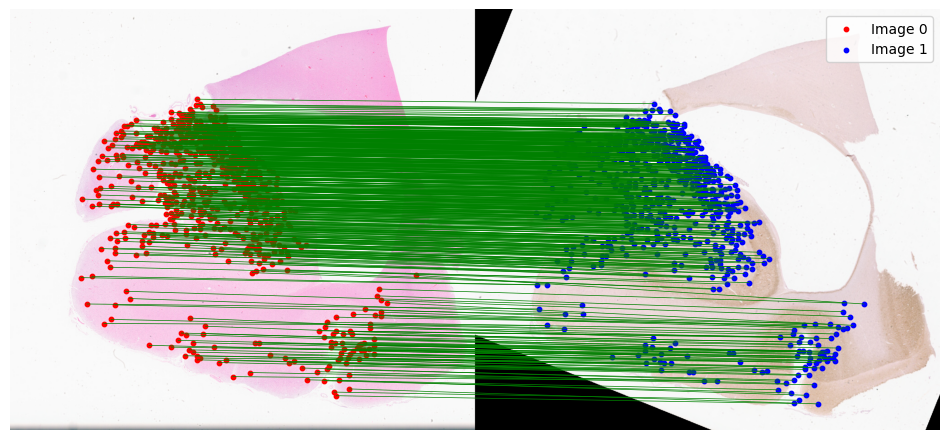

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Move images and points from GPU to CPU and convert to NumPy arrays
image0_np = image0.cpu().permute(1, 2, 0).numpy()  # Shape: (H0, W0, 3)
image1_np = image1.cpu().permute(1, 2, 0).numpy()  # Shape: (H1, W1, 3)
points0_np = points0.cpu().numpy()  # Shape: (K, 2)
points1_np = points1.cpu().numpy()  # Shape: (K, 2)

# Get the width of the first image for offsetting the second image's points
W0 = image0_np.shape[1]
print(image0_np.shape, image1_np.shape)
# Concatenate the images horizontally
combined_image = np.hstack((image0_np, image1_np))  # Shape: (H, W0 + W1, 3)

# Create the plot
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
plt.imshow(combined_image)

# Plot keypoints from the first image (red)
plt.scatter(points0_np[:, 0], points0_np[:, 1], c='red', s=10, label='Image 0')

# Plot keypoints from the second image (blue), shifted by W0
plt.scatter(points1_np[:, 0] + W0, points1_np[:, 1], c='blue', s=10, label='Image 1')

# Draw lines between matching points (green)
for i in range(len(points0_np)):
    plt.plot(
        [points0_np[i, 0], points1_np[i, 0] + W0],
        [points0_np[i, 1], points1_np[i, 1]],
        'g-',  # Green lines
        linewidth=0.5
    )

# Add a legend and display the plot
plt.legend()
plt.axis('off')  # Optional: hide axes for a cleaner look
plt.show()

Mean TRE: 26.44 pixels
Median TRE: 25.61 pixels
Max TRE: 73.06 pixels


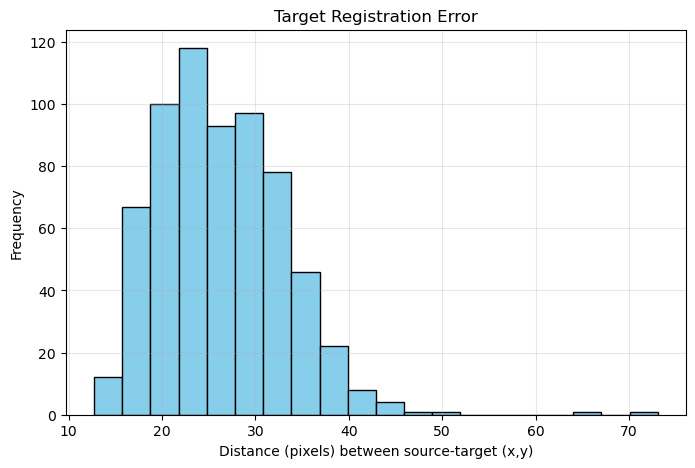

In [ ]:

# TRE. Difference in x and y coordinates. Euclidean distance for each pair
dx = points0_np[:, 0] - points1_np[:, 0]  
dy = points0_np[:, 1] - points1_np[:, 1] 
distances = np.sqrt(dx**2 + dy**2)

mean_tre = np.mean(distances)
median_tre = np.median(distances)
max_tre = np.max(distances)

print(f"Mean TRE: {mean_tre:.2f} pixels")
print(f"Median TRE: {median_tre:.2f} pixels")
print(f"Max TRE: {max_tre:.2f} pixels")

plt.figure(figsize=(8, 5))
plt.hist(distances, bins=20, color='skyblue', edgecolor='black')
plt.title('Target Registration Error')
plt.xlabel('Distance (pixels) between source-target (x,y)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()